# TabPFN for Uplift Modeling with Meta-Learners (ACTG 175)

This notebook evaluates whether TabPFN can improve uplift modeling performance when used inside meta-learners compared to traditional models (LinearRegression, LightGBM) and a standalone causal model (CausalPFN).

**Dataset**: AIDS Clinical Trials Group Study 175 (ACTG 175) — a randomized controlled trial comparing ZDV monotherapy vs. combination therapies in HIV-infected adults.
- 1054 samples (arms 0 & 1 only), 16 covariates, binary outcome = survival indicator (Y = 1 − cid: 1=survived/censored, 0=failure/death)
- Treatment: `trt` restricted to arms 0 (ZDV monotherapy) and 1 (ZDV + ddI), giving a clean binary RCT with ~532 vs ~522 samples
- Restricting to arms 0 and 1 avoids conflating distinct causal estimands from the three combination therapies

**Evaluation protocol**:
- 50 repeated stratified train/test splits (80/20, stratified on T × Y)
- All models trained on training set only, evaluated on held-out test set
- R-learner (NonParamDML) and DR-learner (DRLearner) use 5-fold cross-fitting within the training data for nuisance estimation
- LightGBM hyperparameters tuned once per split via RandomizedSearchCV (15 iterations, 3-fold CV)

**Metrics** (all computed on the test set per split):
- **AUQC**: Area between the Qini curve and its diagonal (the random-model baseline). Expected value under a random CATE ranking is 0 by construction; significance test checks whether the 95% CI excludes zero.
- **Policy Gain @k%** (k = 10, 20, 30, 40): IPW policy value for treating the top-k% minus the random k% baseline — already measures improvement over random targeting

**Models**:
- Meta-learners: S, T, X, R (NonParamDML, cv=5), DR (DRLearner, cv=5)
- Base models: LinearRegression, LightGBM (tuned), TabPFN, TabICL
- Standalone: CausalForestDML (cv=5, LightGBM nuisance), CausalPFN


## 1. Setup and Imports

In [1]:
# ── IMPORTS ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.stats as st
import pickle
from collections import defaultdict
from datetime import datetime
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, KFold
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
import tabpfn
from tabpfn import TabPFNRegressor, TabPFNClassifier
from tabicl import TabICLRegressor, TabICLClassifier
from econml.metalearners import SLearner, TLearner, XLearner
from econml.dml import NonParamDML, CausalForestDML
from econml.dr import DRLearner
import matplotlib.pyplot as plt
import warnings
import torch

from causalpfn import CATEEstimator
from causalpfn.evaluation import get_qini_curve as _get_qini_curve

def _compute_auqc(qini_curve):
    n = len(qini_curve)
    phi = np.linspace(1/n, 1.0, n)
    diagonal = phi * qini_curve[-1]
    return np.trapz(qini_curve - diagonal, phi)

def get_qini_curve(T, Y, cate):
    # _compute_auqc always computes the diagonal-subtracted area
    curve, _ = _get_qini_curve(T, Y, cate, normalize=False)
    return curve, _compute_auqc(curve)


# ── DEVICE DETECTION ─────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'cpu'
else:
    device = 'cpu'
print(f"TabPFN {tabpfn.__version__} | device: {device}")

# CausalPFN does not support MPS
causalpfn_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"CausalPFN device: {causalpfn_device}")

# TabICL does not support MPS — fall back to CPU
tabicl_device = "cpu" if device == "mps" else device
print(f"TabICL device: {tabicl_device}")


# ── EXTRA ─────────────────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)  # no-op if no CUDA
warnings.filterwarnings("ignore")

import os
os.environ["TABPFN_NO_TELEMETRY_PROMPT"] = "1"  # must be set before tabpfn import
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Results output directory — timestamped to avoid overwriting previous runs
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('results', f'exp_05_ACTG_{RUN_ID}')
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")

TabPFN 7.1.1 | device: cpu
CausalPFN device: cpu
TabICL device: cpu
Results directory: results/exp_05_ACTG_20260414_120859


## 2. Helper Functions

LightGBM tuning via `RandomizedSearchCV` (15 iterations, 3-fold CV, 3 hyperparameters). IPW-based policy value estimation for top-k% targeting. Qini curve interpolation. AUQC is computed as the area between the Qini curve and its diagonal (the random-model baseline), so its expected value under a random CATE ranking is 0 by construction.

In [2]:
# ── TUNING ────────────────────────────────────────────────────
# LightGBM hyperparameter search space
LGBM_GRID = {
    'num_leaves':        [15, 31, 63],
    'min_child_samples': [20, 50, 100],
    #'learning_rate':     [0.01, 0.05, 0.1],
    'n_estimators':      [200, 500, 1000],
}

N_ITER_STRONG = 30   # RandomizedSearchCV draws
N_EST         = 1000  # base tree count (overridden by grid)
NUISANCE_CV   = 5    # K-fold cross-fitting for R- and DR-learner nuisance models

# LightGBM Tuning
def tune_lgbm(X, y, classifier=False, stratify=None, n_iter=N_ITER_STRONG, seed=42):
    """Tune LGBM via RandomizedSearchCV. Returns best_params_ dict.

    - classifier=False  → LGBMRegressor, scored by neg_MSE
    - classifier=True   → LGBMClassifier, scored by neg_log_loss
    - stratify          → use StratifiedKFold on this variable (regression only);
                          if None, falls back to KFold with adaptive n_splits
    """
    X = np.asarray(X)

    if classifier:
        # Propensity Model (classification)
        base    = LGBMClassifier(n_estimators=N_EST, random_state=seed, verbose=-1)
        scoring = 'neg_log_loss'
        cv      = list(StratifiedKFold(3, shuffle=True, random_state=seed).split(X, y))
    else:
        # Outcome Model (regression): S-, R-, and DR-learner
        base    = LGBMRegressor(n_estimators=N_EST, random_state=seed, verbose=-1)
        scoring = 'neg_mean_squared_error'
        if stratify is not None:
            cv  = list(StratifiedKFold(3, shuffle=True, random_state=seed).split(X, stratify))
        else:
            # Single Treatment Arm: T- and X-learner
            n_splits = min(3, max(2, len(y) // 20))
            cv  = list(KFold(n_splits, shuffle=True, random_state=seed).split(X))

    search = RandomizedSearchCV(
        base, LGBM_GRID, n_iter=n_iter, scoring=scoring,
        cv=cv, n_jobs=1, random_state=seed,
    )

    search.fit(X, y)
    return search.best_params_


# Pseudo-Outcome Tuning: X-, R-, and DR-learner final-stage models
def make_lgbm_final(seed=42):
    """LGBM wrapped in RandomizedSearchCV for final-stage tuning on pseudo-outcomes."""
    return RandomizedSearchCV(
        LGBMRegressor(n_estimators=N_EST, random_state=seed, verbose=-1),
        LGBM_GRID, n_iter=N_ITER_STRONG, cv=3, scoring='neg_mean_squared_error',
        n_jobs=1, random_state=seed,
    )


# ── Metrics ───────────────────────────────────────────────────
TOP_K_PERCENTAGES = [10, 20, 30, 40]

def calculate_topk_policy_metrics(y_true, treatment, predicted_ite,
                                   k_percentages=TOP_K_PERCENTAGES, min_treated=3, min_control=3):
    """IPW policy value for top-k% treatment policies (unbiased under RCT design)."""
    treatment = np.asarray(treatment)
    y_true = np.asarray(y_true)
    predicted_ite = np.asarray(predicted_ite).flatten()
    n = len(y_true)
    sorted_idx = np.argsort(-predicted_ite)
    e = treatment.mean()
    treat_all = (treatment * y_true / e).mean() if e > 0 else np.nan
    treat_none = ((1 - treatment) * y_true / (1 - e)).mean() if e < 1 else np.nan
    metrics = {}
    for k in k_percentages:
        n_top = int(np.ceil(n * k / 100))
        pi = np.zeros(n)
        pi[sorted_idx[:n_top]] = 1.0
        n_t_top = (treatment[sorted_idx[:n_top]] == 1).sum()
        n_c_bot = (treatment[sorted_idx[n_top:]] == 0).sum()
        if n_t_top < min_treated or n_c_bot < min_control:
            pv = np.nan
        else:
            pv = (pi * treatment * y_true / e + (1 - pi) * (1 - treatment) * y_true / (1 - e)).mean()
        rand_k = (k / 100) * treat_all + (1 - k / 100) * treat_none if not (np.isnan(treat_all) or np.isnan(treat_none)) else np.nan
        gain = pv - rand_k if not (np.isnan(pv) or np.isnan(rand_k)) else np.nan
        metrics[f'policy_value_{k}'] = pv
        metrics[f'random_policy_{k}'] = rand_k
        metrics[f'policy_gain_{k}'] = gain
    return metrics

def interpolate_qini_curve(qini_curve, n_grid=101):
    n = len(qini_curve)
    x_orig = np.concatenate([[0.0], np.linspace(1/n, 1.0, n)])
    y_orig = np.concatenate([[0.0], qini_curve])
    return np.interp(np.linspace(0.0, 1.0, n_grid), x_orig, y_orig)

## 3. Data Loading

Load the ACTG 175 dataset from the UCI ML Repository and define stratification variables and run configuration.

In [3]:
# --- Load data ---
from ucimlrepo import fetch_ucirepo

DATA_DIR  = os.path.join(os.path.dirname(os.path.abspath('ACTG.ipynb')), 'data')
FEAT_PATH = os.path.join(DATA_DIR, 'actg175_features.csv')
TARG_PATH = os.path.join(DATA_DIR, 'actg175_targets.csv')

if os.path.exists(FEAT_PATH) and os.path.exists(TARG_PATH):
    features_df = pd.read_csv(FEAT_PATH)
    targets_df  = pd.read_csv(TARG_PATH)
    print("Loaded from local cache.")
else:
    print("Fetching from UCI ML Repository...")
    actg175 = fetch_ucirepo(id=890)
    features_df = actg175.data.features.reset_index(drop=True)
    targets_df  = actg175.data.targets.reset_index(drop=True)
    os.makedirs(DATA_DIR, exist_ok=True)
    features_df.to_csv(FEAT_PATH, index=False)
    targets_df.to_csv(TARG_PATH, index=False)
    print(f"Downloaded and cached to {DATA_DIR}")

# Restrict to arms 0 (ZDV monotherapy) and 1 (ZDV + ddI) for a clean binary RCT.
# Aggregating all non-ZDV arms into treat=1 conflates distinct causal estimands;
# arms 0 and 1 give ~532 vs ~522 samples with a single well-defined intervention contrast.
arm_mask    = features_df['trt'].isin([0, 1])
features_df = features_df[arm_mask].reset_index(drop=True)
targets_df  = targets_df[arm_mask].reset_index(drop=True)

# Treatment: trt (0 = ZDV monotherapy, 1 = ZDV + ddI)
# Outcome:   Y = cid (1 = failure/death, 0 = censored/survived). Positive CATE means
#            treatment increases failure — so CATE < 0 means treatment helps.
# Features:  baseline covariates only — drop treatment indicators (treat, trt, offtrt),
#            time-to-event (time, post-randomization), post-treatment measurements (cd420, cd820),
#            and redundant binary encoding of strat (str2).
T_all = features_df['trt'].values.astype(int)
Y_all = targets_df['cid'].values.astype(float)

drop_cols    = ['treat', 'trt', 'offtrt', 'time', 'cd420', 'cd820', 'str2']
feature_cols = [c for c in features_df.columns if c not in drop_cols]
X_all = features_df[feature_cols].reset_index(drop=True)

# --- Stratification variable: interaction of treatment and outcome ---
strat_all    = T_all * 2 + Y_all.astype(int)
strat_labels = {0: 'control+survived', 1: 'control+failure', 2: 'treated+survived', 3: 'treated+failure'}

# --- Data summary ---
n_total    = len(X_all)
n_treated  = int(T_all.sum())
n_control  = n_total - n_treated
n_failure  = int(Y_all.sum())
ate        = Y_all[T_all == 1].mean() - Y_all[T_all == 0].mean()

print("=" * 55)
print("ACTG 175 Dataset Summary (arms 0 & 1 only)")
print("=" * 55)
print(f"  Total samples  : {n_total}")
print(f"  Treated        : {n_treated}  ({100*n_treated/n_total:.1f}%)")
print(f"  Control        : {n_control}  ({100*n_control/n_total:.1f}%)")
print(f"  Features ({len(feature_cols):2d})  : {feature_cols}")
print(f"  Outcome (Y)    : {n_failure} failures ({100*n_failure/n_total:.1f}%) [Y = cid, 1=failure]")
print(f"  ATE (naive)    : {ate:+.4f}  (treated mean - control mean)")
print()
print("Outcome by treatment arm:")
print(f"  Treated  failure rate: {Y_all[T_all==1].mean():.4f}")
print(f"  Control  failure rate: {Y_all[T_all==0].mean():.4f}")
print()
print("Stratification strata counts (T x Y):")
for val, label in strat_labels.items():
    count = (strat_all == val).sum()
    min_needed = int(np.ceil(count * 0.2))
    print(f"  {label:<26}: {count:3d} total, ~{min_needed:2d} in test  "
          f"{'OK' if count >= 10 else 'WARNING: very small'}")

# --- Configuration ---
# Set DRY_RUN = True for a quick end-to-end check (2 splits, fewer trees)
DRY_RUN = False

N_SPLITS     = 1   if DRY_RUN else 10
N_GRID       = 101

# --- Storage ---
results     = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
qini_curves = defaultdict(lambda: defaultdict(list))

META_LEARNERS = ['S', 'T', 'X', 'R', 'DR', 'CF', 'CausalPFN']
BASE_MODELS   = ['LinearRegression', 'LightGBM', 'TabPFN', 'TabICL']

print(f"\nConfiguration: {N_SPLITS} repeated stratified splits (80/20), DRY_RUN={DRY_RUN}")


Loaded from local cache.
ACTG 175 Dataset Summary (arms 0 & 1 only)
  Total samples  : 1054
  Treated        : 522  (49.5%)
  Control        : 532  (50.5%)
  Features (16)  : ['age', 'wtkg', 'hemo', 'homo', 'drugs', 'karnof', 'oprior', 'z30', 'zprior', 'preanti', 'race', 'gender', 'strat', 'symptom', 'cd40', 'cd80']
  Outcome (Y)    : 284 failures (26.9%) [Y = cid, 1=failure]
  ATE (naive)    : -0.1429  (treated mean - control mean)

Outcome by treatment arm:
  Treated  failure rate: 0.1973
  Control  failure rate: 0.3402

Stratification strata counts (T x Y):
  control+survived          : 351 total, ~71 in test  OK
  control+failure           : 181 total, ~37 in test  OK
  treated+survived          : 419 total, ~84 in test  OK
  treated+failure           : 103 total, ~21 in test  OK

Configuration: 10 repeated stratified splits (80/20), DRY_RUN=False


## 4. Evaluation

Run all models across the repeated stratified splits. Per split we:
1. Tune LightGBM once (regressor + classifier), reuse across all meta-learners
2. Fit S/T/X/R/DR-learners with 3 base models + CausalForestDML + CausalPFN, predict on test set
3. Store AUQC (diagonal-subtracted) and policy gains for later aggregation

**Stratification**: splits are stratified on `T × Y` — a 4-category interaction of treatment and binary outcome — to ensure each split preserves the failure rate within each treatment arm.


In [4]:
import time

print(f"Running {N_SPLITS} repeated stratified splits (80/20)...\n")

for split_idx in range(N_SPLITS):
    rs = 42 + split_idx
    X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
        X_all, T_all, Y_all, test_size=0.2, random_state=rs, stratify=strat_all)
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)

    ate_test = Y_test[T_test == 1].mean() - Y_test[T_test == 0].mean()
    print(f"\n{'='*60}")
    print(f"Split {split_idx + 1}/{N_SPLITS}  |  test ATE: {ate_test:+.4f}"
          f"  (n={len(T_test)}, treated={T_test.sum()}, control={(T_test==0).sum()})")
    print(f"{'='*60}")

    # ── Arm splits (needed for T- and X-learner tuning) ──────────────────────
    trt_mask  = T_train == 1
    ctrl_mask = T_train == 0
    X_trt, Y_trt = X_train[trt_mask].reset_index(drop=True), Y_train[trt_mask]
    X_ctrl, Y_ctrl = X_train[ctrl_mask].reset_index(drop=True), Y_train[ctrl_mask]


    # ── LightGBM hyperparameter tuning ───────────────────────────────────────────
    print(f"  [LightGBM] Tuning hyperparameters...", end=" ", flush=True)
    t0 = time.time()
    X_with_T        = np.column_stack([X_train, T_train])
    params_s        = tune_lgbm(X_with_T, Y_train, stratify=T_train)  # S-learner outcome (X+T features)
    params_outcome  = tune_lgbm(X_train,  Y_train, stratify=T_train)  # outcome nuisance (R/DR)
    params_prop     = tune_lgbm(X_train,  T_train, classifier=True)   # propensity model
    params_ctrl     = tune_lgbm(X_ctrl,   Y_ctrl)                     # T/X control arm outcome
    params_trt      = tune_lgbm(X_trt,    Y_trt)                      # T/X treated arm outcome
    print(f"  LightGBM tuning: {time.time() - t0:.1f}s")


    # ── Model configs ────────────────────────────────────────────────────────
    # Local shorthands to avoid repeating constructor args across 4 models × 11 roles
    def _lgbm_r(params, seed=42): return LGBMRegressor(random_state=seed, verbose=-1, **params)
    def _lgbm_c(params, seed=42): return LGBMClassifier(random_state=seed, verbose=-1, **params)
    def _tabpfn_r(seed=None):     return TabPFNRegressor(device=device, random_state=rs if seed is None else seed)
    def _tabpfn_c(seed=None):     return TabPFNClassifier(device=device, random_state=rs if seed is None else seed)
    def _tabicl_r(seed=None):     return TabICLRegressor(device=tabicl_device, random_state=rs if seed is None else seed, verbose=False)
    def _tabicl_c(seed=None):     return TabICLClassifier(device=tabicl_device, random_state=rs if seed is None else seed, verbose=False)

    configs = {
        'LinearRegression': {
            's_model':       LinearRegression(),
            't_models':      (LinearRegression(), LinearRegression()),
            'x_models':      (LinearRegression(), LinearRegression()),
            'x_cate':        (LinearRegression(), LinearRegression()),
            'x_propensity':  LogisticRegression(max_iter=1000, random_state=44),
            'r_model_y':     LinearRegression(),
            'r_model_t':     LogisticRegression(max_iter=1000, random_state=42),
            'r_model_final': LinearRegression(),
            'dr_regression': LinearRegression(),
            'dr_propensity': LogisticRegression(max_iter=1000, random_state=43),
            'dr_final':      LinearRegression(),
        },
        'LightGBM': {
            's_model':       _lgbm_r(params_s),
            # T/X-learner: (models[0]=control arm, models[1]=treated arm) — EconML convention
            't_models':      (_lgbm_r(params_ctrl, 42), _lgbm_r(params_trt, 43)),
            'x_models':      (_lgbm_r(params_ctrl, 42), _lgbm_r(params_trt, 43)),
            'x_cate':        (make_lgbm_final(46), make_lgbm_final(47)),
            'x_propensity':  _lgbm_c(params_prop, 44),
            'r_model_y':     _lgbm_r(params_outcome, 42),
            'r_model_t':     _lgbm_c(params_prop, 43),
            'r_model_final': make_lgbm_final(44),
            'dr_regression': _lgbm_r(params_outcome, 42),
            'dr_propensity': _lgbm_c(params_prop, 44),
            'dr_final':      make_lgbm_final(45),
        },
        'TabPFN': {
            's_model':       _tabpfn_r(),
            't_models':      (_tabpfn_r(), _tabpfn_r(rs+1)),
            'x_models':      (_tabpfn_r(), _tabpfn_r(rs+1)),
            'x_cate':        (_tabpfn_r(rs+2), _tabpfn_r(rs+3)),
            'x_propensity':  _tabpfn_c(),
            'r_model_y':     _tabpfn_r(),
            'r_model_t':     _tabpfn_c(),
            'r_model_final': make_lgbm_final(44),  # TabPFN not suited for residual-on-residual
            'dr_regression': _tabpfn_r(),
            'dr_propensity': _tabpfn_c(),
            'dr_final':      _tabpfn_r(rs+2),
        },
        'TabICL': {
            's_model':       _tabicl_r(),
            # T/X-learner: (models[0]=control arm, models[1]=treated arm) — EconML convention
            't_models':      (_tabicl_r(), _tabicl_r(rs+1)),
            'x_models':      (_tabicl_r(), _tabicl_r(rs+1)),
            'x_cate':        (_tabicl_r(rs+2), _tabicl_r(rs+3)),
            'x_propensity':  _tabicl_c(),
            'r_model_y':     _tabicl_r(),
            'r_model_t':     _tabicl_c(),
            'r_model_final': make_lgbm_final(44),  # TabICL not suited for residual-on-residual
            'dr_regression': _tabicl_r(),
            'dr_propensity': _tabicl_c(),
            'dr_final':      _tabicl_r(rs+2),
        },
    }

    def evaluate(meta, name, te_pred):
        """Compute and store all metrics for one (meta, name, split).
        Y = cid (failure=1): CATE < 0 means treatment helps (reduces failure).
        Negate te so Qini ranks highest-benefit individuals first.
        """
        te = np.asarray(te_pred).flatten()
        curve, auqc = get_qini_curve(T_test, Y_test, -te)
        results[meta][name]['auqc'].append(auqc)
        results[meta][name]['g1'].append(float(curve[-1]))
        qini_curves[meta][name].append(interpolate_qini_curve(curve, n_grid=N_GRID))
        topk = calculate_topk_policy_metrics(-Y_test, T_test, -te)  # negate Y and te: policy value = survival rate, positive gain = better
        for k in TOP_K_PERCENTAGES:
            results[meta][name][f'gain_{k}'].append(topk[f'policy_gain_{k}'])


    # ── Evaluation ────────────────────────────────────────────────────────────
    for name, cfg in configs.items():

        # ── S-Learner ───────────────────────────────────────────────────────────────
        print(f"  [{name}] S-learner...", end=" ", flush=True)
        _t0 = time.time()
        sl = SLearner(overall_model=cfg['s_model'])
        sl.fit(Y_train, T_train, X=X_train)
        evaluate('S', name, sl.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")


        # ── T-Learner ───────────────────────────────────────────────────────────────
        print(f"  [{name}] T-learner...", end=" ", flush=True)
        _t0 = time.time()
        tl = TLearner(models=cfg['t_models'])
        tl.fit(Y_train, T_train, X=X_train)
        evaluate('T', name, tl.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")


        # ── X-Learner ───────────────────────────────────────────────────────────────
        print(f"  [{name}] X-learner...", end=" ", flush=True)
        _t0 = time.time()
        xl = XLearner(models=cfg['x_models'], cate_models=cfg['x_cate'], propensity_model=cfg['x_propensity'])
        xl.fit(Y_train, T_train, X=X_train)
        evaluate('X', name, xl.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")


        # ── R-learner (NonParamDML) ──────────────────────────────────────────────
        print(f"  [{name}] R-learner (NonParamDML, cv={NUISANCE_CV})...", end=" ", flush=True)
        _t0 = time.time()
        rl = NonParamDML(
            model_y=cfg['r_model_y'], model_t=cfg['r_model_t'],
            model_final=cfg['r_model_final'], discrete_treatment=True, cv=NUISANCE_CV
        )
        rl.fit(Y_train, T_train, X=X_train)
        evaluate('R', name, rl.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")


        # ── DR-learner ───────────────────────────────────────────────────────────
        print(f"  [{name}] DR-learner (DRLearner, cv={NUISANCE_CV})...", end=" ", flush=True)
        _t0 = time.time()
        dl = DRLearner(
            model_regression=cfg['dr_regression'],
            model_propensity=cfg['dr_propensity'],
            model_final=cfg['dr_final'],
            min_propensity=0.05,
            cv=NUISANCE_CV
        )
        dl.fit(Y_train, T_train, X=X_train)
        evaluate('DR', name, dl.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")


    # ── Causal Forest (CausalForestDML) ───────────────────────────────────────
    try:
        print(f"  [CausalForest] DML (cv={NUISANCE_CV})...", end=" ", flush=True)
        _t0 = time.time()
        cf = CausalForestDML(
            model_y=LGBMRegressor(random_state=42, verbose=-1, **params_outcome),
            model_t=LGBMClassifier(random_state=43, verbose=-1, **params_prop),
            discrete_treatment=True,
            cv=NUISANCE_CV,
            n_estimators=200,
            min_samples_leaf=5,
            random_state=rs,
        )
        cf.tune(Y_train, T_train, X=X_train)
        cf.fit(Y_train, T_train, X=X_train)
        evaluate('CF', 'CausalForest', cf.effect(X_test))
        print(f"done. ({time.time() - _t0:.1f}s)")
    except Exception as exc:
        print(f"ERROR\n  CausalForest error on split {split_idx + 1}: {exc}")


    # ── CausalPFN ───────────────────────────────────────────────────────────────
    try:
        print(f"  [CausalPFN]...", end=" ", flush=True)
        _t0 = time.time()
        cpfn = CATEEstimator(device=causalpfn_device, verbose=False)

        X_cpfn_train = np.asarray(X_train, dtype=np.float32)
        T_cpfn_train = np.asarray(T_train, dtype=np.float32).ravel()
        Y_cpfn_train = np.asarray(Y_train, dtype=np.float32).ravel()
        X_cpfn_test  = np.asarray(X_test, dtype=np.float32)

        cpfn.fit(X_cpfn_train, T_cpfn_train, Y_cpfn_train)
        te = cpfn.estimate_cate(X_cpfn_test)

        if "torch" in str(type(te)):
            te = te.detach().cpu().numpy()

        te = np.asarray(te, dtype=np.float32).reshape(-1)
        evaluate('CausalPFN', 'CausalPFN', te)
        print(f"done. ({time.time() - _t0:.1f}s)")
    except Exception as exc:
        print(f"ERROR\n  CausalPFN error on split {split_idx + 1}: {exc}")

print(f"\nDone. {N_SPLITS} splits evaluated.")

Running 10 repeated stratified splits (80/20)...


Split 1/10  |  test ATE: -0.1396  (n=211, treated=105, control=106)
  [LightGBM] Tuning hyperparameters...   LightGBM tuning: 335.1s
  [LinearRegression] S-learner... done. (0.0s)
  [LinearRegression] T-learner... done. (0.0s)
  [LinearRegression] X-learner... done. (0.1s)
  [LinearRegression] R-learner (NonParamDML, cv=5)... done. (0.3s)
  [LinearRegression] DR-learner (DRLearner, cv=5)... done. (0.2s)
  [LightGBM] S-learner... done. (0.3s)
  [LightGBM] T-learner... done. (0.2s)
  [LightGBM] X-learner... done. (84.9s)
  [LightGBM] R-learner (NonParamDML, cv=5)... done. (84.6s)
  [LightGBM] DR-learner (DRLearner, cv=5)... done. (84.3s)
  [TabPFN] S-learner... done. (36.8s)
  [TabPFN] T-learner... done. (26.3s)
  [TabPFN] X-learner... done. (76.8s)
  [TabPFN] R-learner (NonParamDML, cv=5)... done. (407.7s)
  [TabPFN] DR-learner (DRLearner, cv=5)... done. (495.7s)
  [TabICL] S-learner... done. (9.1s)
  [TabICL] T-learner... done. (8.3s)


## Save Results to Disk

In [5]:
# --- Save results to disk ---
_save_path = os.path.join(RESULTS_DIR, 'actg175_results.pkl')
with open(_save_path, 'wb') as f:
    pickle.dump({
        'results': {m: {n: dict(d) for n, d in v.items()} for m, v in results.items()},
        'qini_curves': {m: {n: list(c) for n, c in v.items()} for m, v in qini_curves.items()},
        'N_SPLITS': N_SPLITS,
        'N_GRID': N_GRID,
        'META_LEARNERS': META_LEARNERS,
        'BASE_MODELS': BASE_MODELS,
        'TOP_K_PERCENTAGES': TOP_K_PERCENTAGES,
    }, f)
print(f"Results saved to {_save_path}")

Results saved to results/exp_05_ACTG_20260414_120859/actg175_results.pkl


## 5. Results

We aggregate per-split metrics across the 50 repetitions and report mean ± SE.

**Reported metrics**:
- AUQC (area between Qini curve and its diagonal): mean ± SE, 95% CI, significant if CI excludes zero. Expected value under a random CATE ranking is 0 by construction.
- Gain@10/20/30/40%: mean ± SE (already a delta: policy value minus random targeting baseline)


In [6]:
# --- Load results from disk (run this cell instead of the evaluation loop when working locally) ---
# with open('<path-to>/actg175_results.pkl', 'rb') as f:
#     _data = pickle.load(f)
# results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)), {
#     m: defaultdict(lambda: defaultdict(list), {n: defaultdict(list, d) for n, d in v.items()})
#     for m, v in _data['results'].items()
# })
# qini_curves = defaultdict(lambda: defaultdict(list), {
#     m: defaultdict(list, v) for m, v in _data['qini_curves'].items()
# })
# N_SPLITS       = _data['N_SPLITS']
# N_GRID         = _data['N_GRID']
# META_LEARNERS  = _data['META_LEARNERS']
# BASE_MODELS    = _data['BASE_MODELS']
# TOP_K_PERCENTAGES = _data['TOP_K_PERCENTAGES']
# print(f"Loaded results: {N_SPLITS} splits, {len(META_LEARNERS)} meta-learners")

RESULTS ACROSS 10 SPLITS (mean ± SE) — ranked by AUQC
AUQC is diagonal-subtracted: expected value under random model is 0 by construction.

--- AUQC (diagonal-subtracted) ---
     Meta             Base  AUQC Mean  AUQC SE            AUQC CI AUQC Sig
        S           TabPFN    -1.6759   0.8337  [-3.5620, 0.2101]         
       DR         LightGBM    -1.1659   0.3820 [-2.0301, -0.3017]        *
        S           TabICL    -0.9935   0.7620  [-2.7172, 0.7303]         
        R           TabICL    -0.6891   0.5404  [-1.9116, 0.5334]         
        R           TabPFN    -0.5105   0.6039  [-1.8766, 0.8556]         
        R         LightGBM    -0.4607   0.5023  [-1.5970, 0.6756]         
       CF     CausalForest    -0.3781   0.6211  [-1.7832, 1.0270]         
       DR           TabICL    -0.3121   0.5148  [-1.4767, 0.8525]         
        X           TabICL    -0.2634   0.4105  [-1.1921, 0.6653]         
        T           TabICL    -0.1010   0.3984  [-1.0023, 0.8002]         


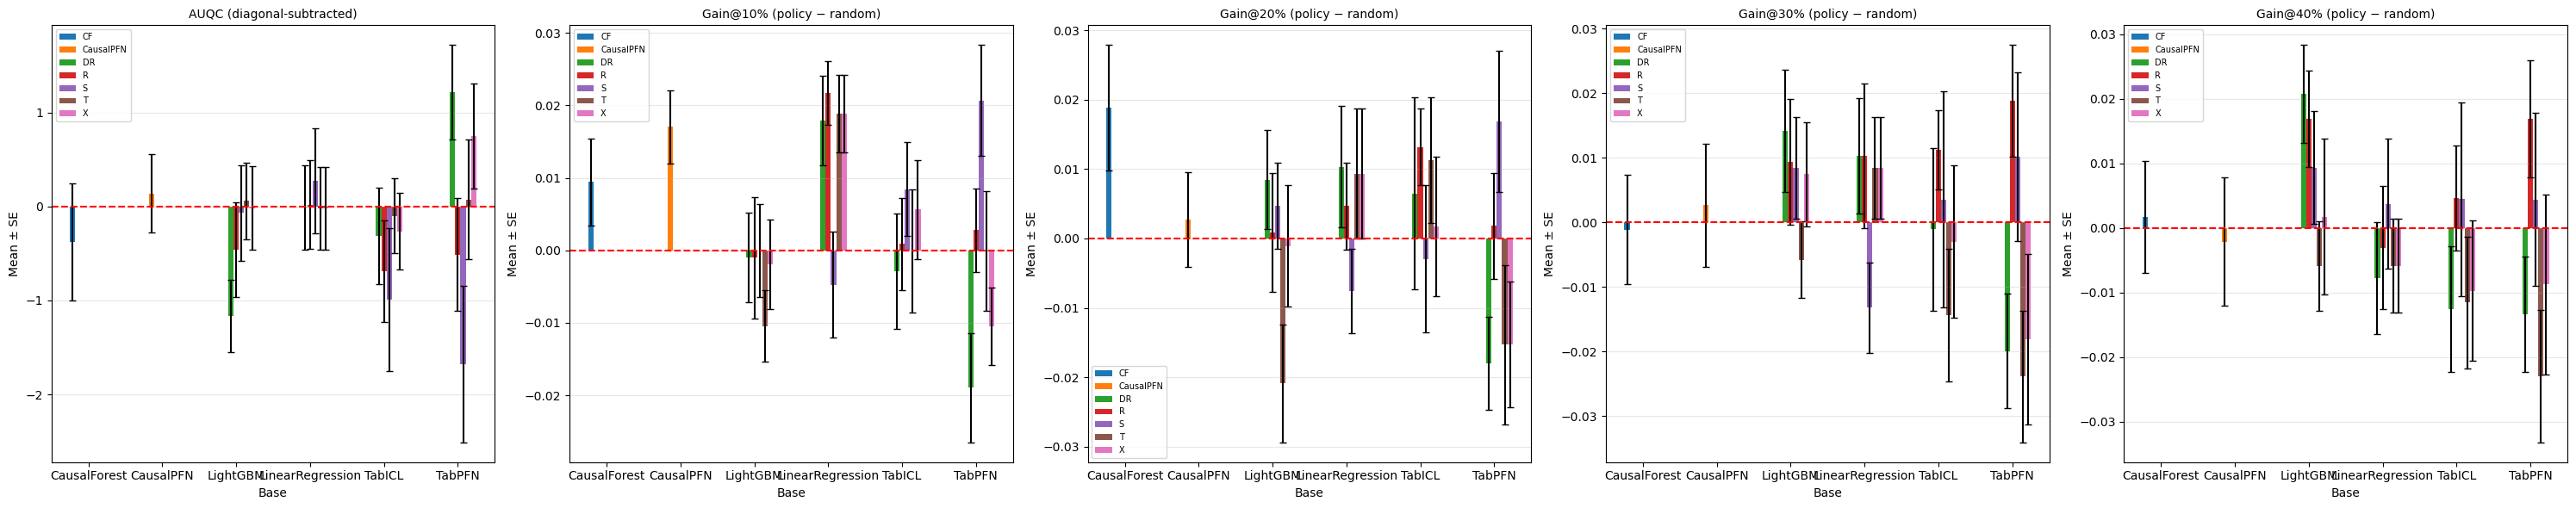

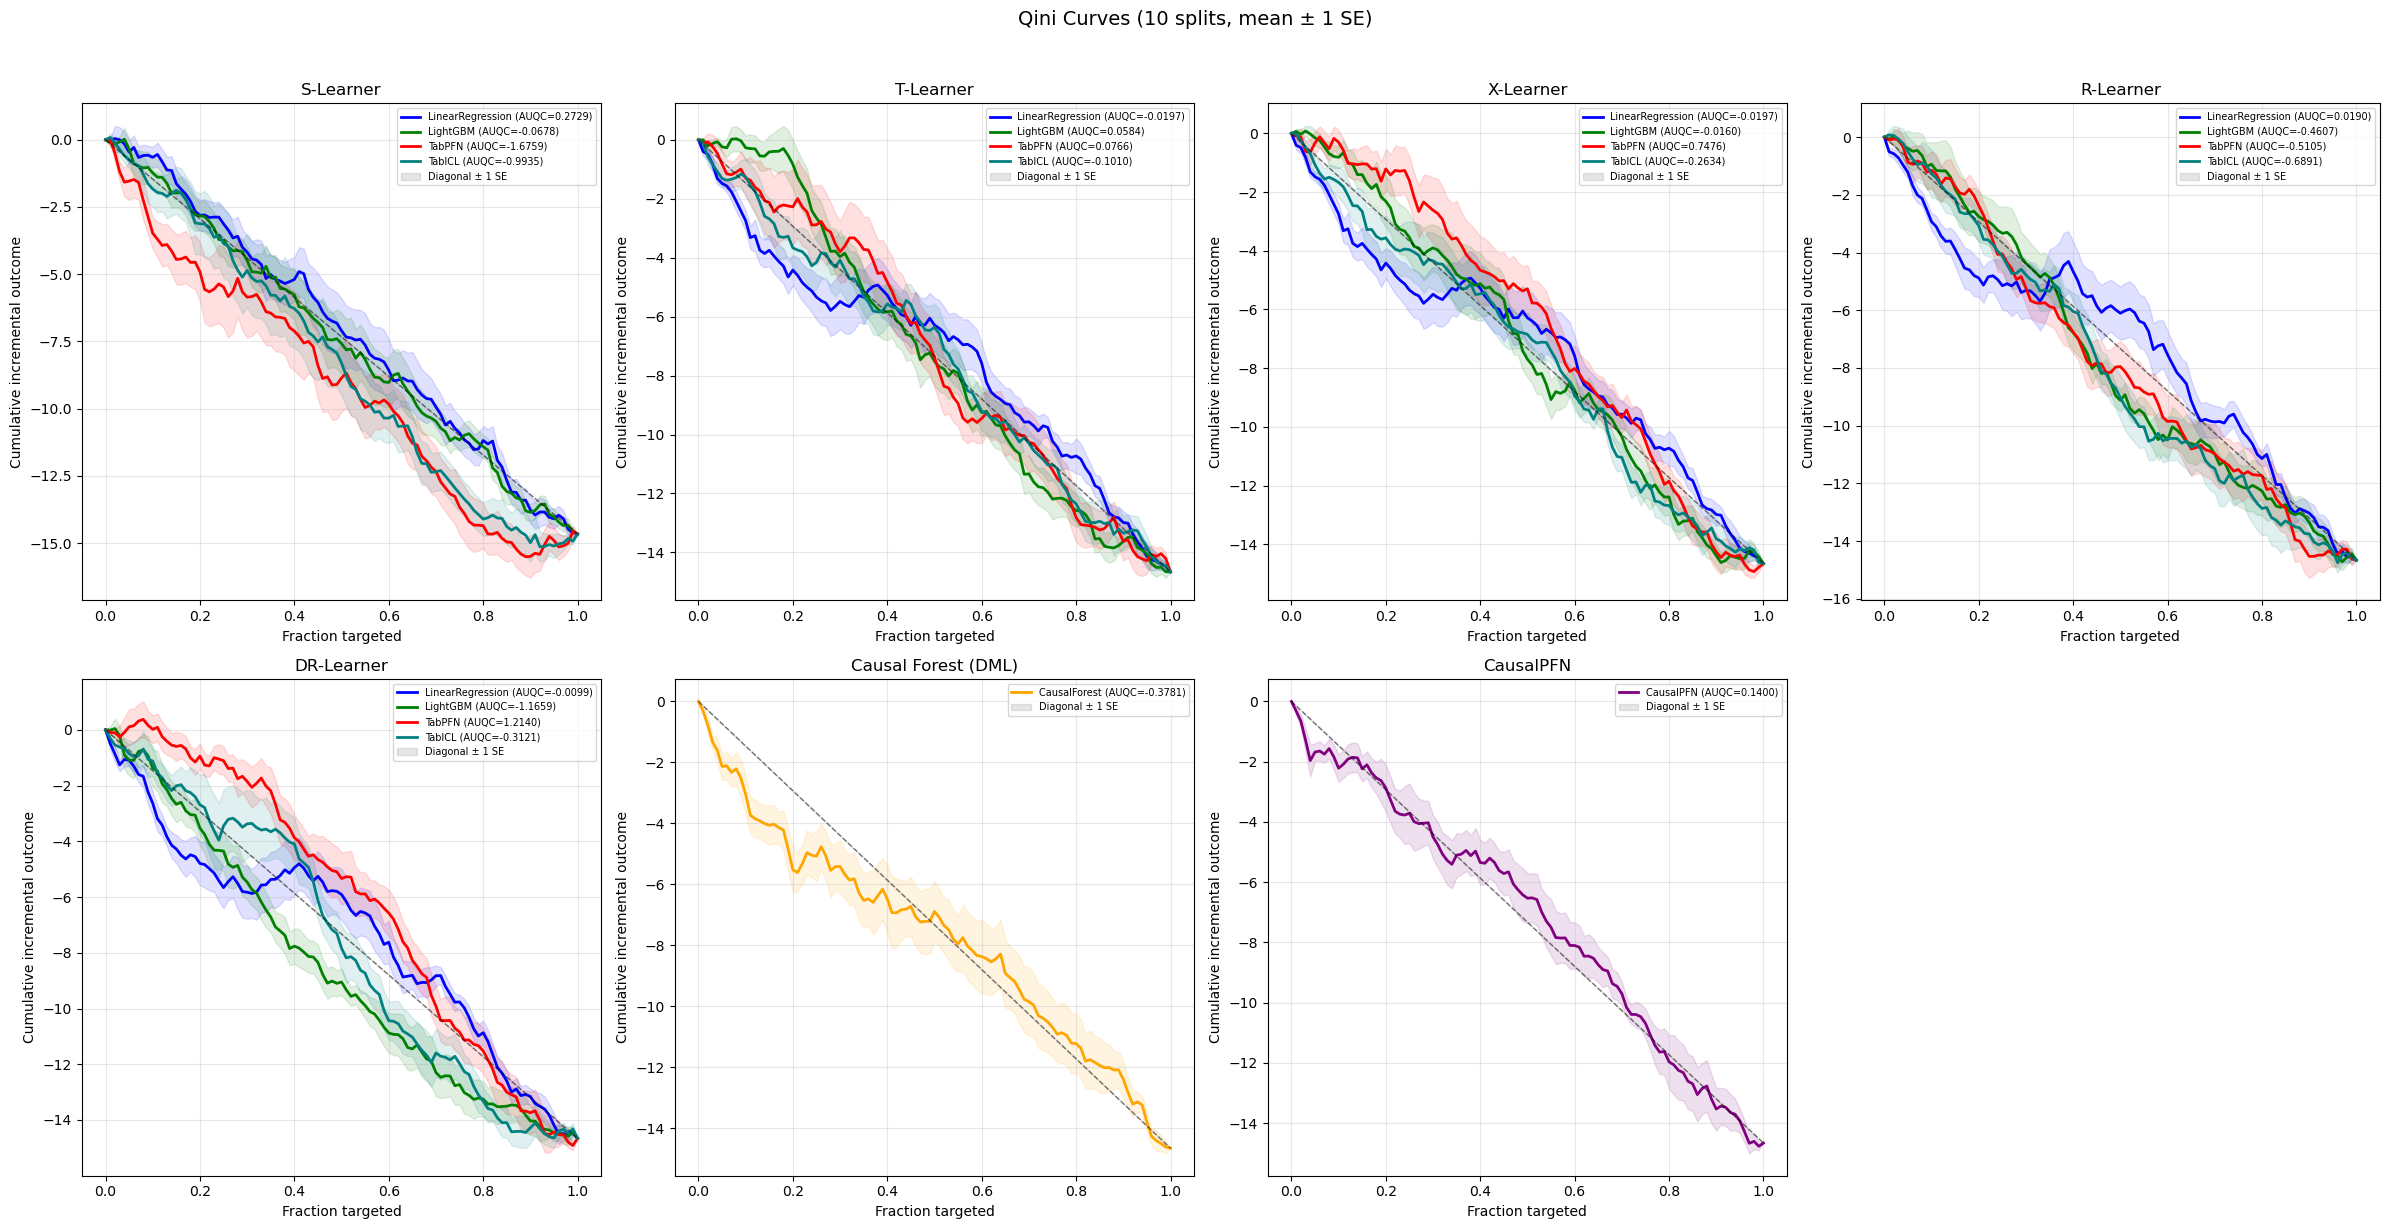

In [7]:
# --- Aggregate ---
STANDALONE_MODELS = {'CausalPFN': 'CausalPFN', 'CF': 'CausalForest'}

rows = []
for meta in META_LEARNERS:
    if meta in STANDALONE_MODELS:
        model_list = [STANDALONE_MODELS[meta]]
    else:
        model_list = BASE_MODELS
    for name in model_list:
        d = results[meta][name]
        if not d['auqc']:
            continue
        row = {'Meta': meta, 'Base': name}

        def agg(vals, label):
            arr = np.array(vals, dtype=float)
            valid = arr[~np.isnan(arr)]
            nv = len(valid)
            row[f'{label} Mean'] = np.nanmean(arr) if nv > 0 else np.nan
            row[f'{label} SE'] = np.nanstd(valid, ddof=1) / np.sqrt(nv) if nv > 1 else np.nan
            row[f'{label} N'] = nv
            if label == 'AUQC' and nv > 1:
                mean = np.nanmean(valid)
                se = np.nanstd(valid, ddof=1) / np.sqrt(nv)
                tcrit = st.t.ppf(0.975, df=nv - 1)
                ci_lo, ci_hi = mean - tcrit * se, mean + tcrit * se
                row[f'{label} CI'] = f"[{ci_lo:.4f}, {ci_hi:.4f}]"
                row[f'{label} Sig'] = '*' if ci_lo > 0 or ci_hi < 0 else ''
            return row

        agg(d['auqc'], 'AUQC')
        for k in TOP_K_PERCENTAGES:
            agg(d[f'gain_{k}'], f'Gain@{k}%')

        rows.append(row)

df = pd.DataFrame(rows)

# Sort by AUQC Mean descending (best first)
df = df.sort_values('AUQC Mean', ascending=True).reset_index(drop=True)  # ascending: most negative AUQC = best (Y=cid, failure outcome)

# --- Display: AUQC ---
print("=" * 110)
print(f"RESULTS ACROSS {N_SPLITS} SPLITS (mean ± SE) — ranked by AUQC")
print("=" * 110)
print("AUQC is diagonal-subtracted: expected value under random model is 0 by construction.")

auqc_cols = ['Meta', 'Base', 'AUQC Mean', 'AUQC SE', 'AUQC CI', 'AUQC Sig']
auqc_cols = [c for c in auqc_cols if c in df.columns]  # CI/Sig absent when N_SPLITS == 1
print("\n--- AUQC (diagonal-subtracted) ---")
print(df[auqc_cols].to_string(index=False, float_format='%.4f'))

# --- Display: Policy Gains ---
for k in TOP_K_PERCENTAGES:
    gain_cols = ['Meta', 'Base', f'Gain@{k}% Mean', f'Gain@{k}% SE']
    existing = [c for c in gain_cols if c in df.columns]
    df_k = df.sort_values(f'Gain@{k}% Mean', ascending=False).reset_index(drop=True)
    print(f"\n--- Policy Gain @{k}% (ranked) ---")
    print(df_k[existing].to_string(index=False, float_format='%.2f'))

# --- Bar charts ---
n_bars = 1 + len(TOP_K_PERCENTAGES)
fig, axes = plt.subplots(1, n_bars, figsize=(6 * n_bars, 6))

# AUQC bar chart
ax = axes[0]
plot_data = df.pivot(index='Base', columns='Meta', values='AUQC Mean')
plot_err = df.pivot(index='Base', columns='Meta', values='AUQC SE')
plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=3, rot=0)
ax.set_title('AUQC (diagonal-subtracted)', fontsize=10)
ax.set_ylabel('Mean ± SE')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=7, loc='best')

# Gain@k% bars
for i, k in enumerate(TOP_K_PERCENTAGES):
    ax = axes[i + 1]
    plot_data = df.pivot(index='Base', columns='Meta', values=f'Gain@{k}% Mean')
    plot_err = df.pivot(index='Base', columns='Meta', values=f'Gain@{k}% SE')
    plot_data.plot(kind='bar', yerr=plot_err, ax=ax, capsize=3, rot=0)
    ax.set_title(f'Gain@{k}% (policy − random)', fontsize=10)
    ax.set_ylabel('Mean ± SE')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bar_charts.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Qini Curves: 2x4 grid ---
x_grid = np.linspace(0, 1, N_GRID)
colors = {'LinearRegression': 'blue', 'LightGBM': 'green', 'TabPFN': 'red',
'TabICL': 'teal', 'CausalForest': 'orange', 'CausalPFN': 'purple'}

# --- Analytical diagonal baseline band ---
# G(1) is a property of (T_test, Y_test) only — identical across all models on the same split.
# Use stored g1 values from S/LightGBM (always present) so the band reflects only
# split-to-split variance in G(1), not model variance.
_g1_per_split = results['S']['LightGBM']['g1']
_all_diag = np.array([x_grid * g1 for g1 in _g1_per_split])
diag_mean = _all_diag.mean(axis=0)
diag_se = _all_diag.std(axis=0) / np.sqrt(len(_all_diag))

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, meta in enumerate(['S', 'T', 'X', 'R', 'DR']):
    ax = axes[idx]
    base_list = BASE_MODELS
    for base in base_list:
        curves_arr = qini_curves[meta][base]
        if curves_arr:
            c = np.array(curves_arr)
            m = c.mean(axis=0)
            s = c.std(axis=0) / np.sqrt(len(c))
            auqc_mean = np.mean(results[meta][base]['auqc'])
            ax.plot(x_grid, m, color=colors[base], linewidth=2,
                    label=f'{base} (AUQC={auqc_mean:.4f})')
            ax.fill_between(x_grid, m - s, m + s, color=colors[base], alpha=0.12)
    ax.fill_between(x_grid, diag_mean - diag_se, diag_mean + diag_se, color='gray', alpha=0.2, label='Diagonal ± 1 SE')
    ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
    ax.set_title(f'{meta}-Learner')
    ax.set_xlabel('Fraction targeted')
    ax.set_ylabel('Cumulative incremental outcome')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

ax = axes[5]
curves_arr = qini_curves['CF']['CausalForest']
if curves_arr:
    c = np.array(curves_arr)
    m = c.mean(axis=0)
    s = c.std(axis=0) / np.sqrt(len(c))
    auqc_mean = np.mean(results['CF']['CausalForest']['auqc'])
    ax.plot(x_grid, m, color=colors['CausalForest'], linewidth=2,
            label=f'CausalForest (AUQC={auqc_mean:.4f})')
    ax.fill_between(x_grid, m - s, m + s, color=colors['CausalForest'], alpha=0.12)
ax.fill_between(x_grid, diag_mean - diag_se, diag_mean + diag_se, color='gray', alpha=0.2, label='Diagonal ± 1 SE')
ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
ax.set_title('Causal Forest (DML)')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental outcome')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

ax = axes[6]
curves_arr = qini_curves['CausalPFN']['CausalPFN']
if curves_arr:
    c = np.array(curves_arr)
    m = c.mean(axis=0)
    s = c.std(axis=0) / np.sqrt(len(c))
    auqc_mean = np.mean(results['CausalPFN']['CausalPFN']['auqc'])
    ax.plot(x_grid, m, color=colors['CausalPFN'], linewidth=2,
            label=f'CausalPFN (AUQC={auqc_mean:.4f})')
    ax.fill_between(x_grid, m - s, m + s, color=colors['CausalPFN'], alpha=0.12)
ax.fill_between(x_grid, diag_mean - diag_se, diag_mean + diag_se, color='gray', alpha=0.2, label='Diagonal ± 1 SE')
ax.plot(x_grid, diag_mean, 'k--', linewidth=1, alpha=0.5)
ax.set_title('CausalPFN')
ax.set_xlabel('Fraction targeted')
ax.set_ylabel('Cumulative incremental outcome')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

axes[7].set_visible(False)

plt.suptitle(f'Qini Curves ({N_SPLITS} splits, mean ± 1 SE)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'qini_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
